In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from itertools import product
from typing import Union
import os

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np


Cargamos el dataset con información sobre el GDP o "producto bruto interno"

In [29]:
df = sm.datasets.macrodata.load_pandas().data
df

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


¿El año es flotante? Que horror.

In [30]:
df["year"] = df["year"].astype(int)
df["quarter"] = df["quarter"].astype(int)

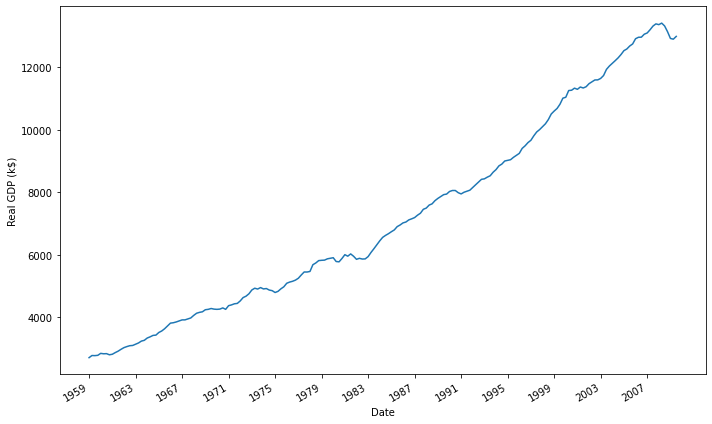

In [31]:
fig, ax = plt.subplots( figsize=(10, 6) )

ax.plot(df['realgdp'])
ax.set_xlabel('Date')
ax.set_ylabel('Real GDP (k$)')

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

Miremos algunas de las otras variables.

realcons: gasto per capita </BR>
realinv: inversión privada </BR>
realgovt: gasto e inversión gubernamental </BR>
realdpi: renta privada real disponible </BR>
cpi: indice de precios

In [32]:
df_s = df[['year', 'quarter', 'realgdp', 'realcons', 'realinv', 'realgovt', 'realdpi', "cpi"]]

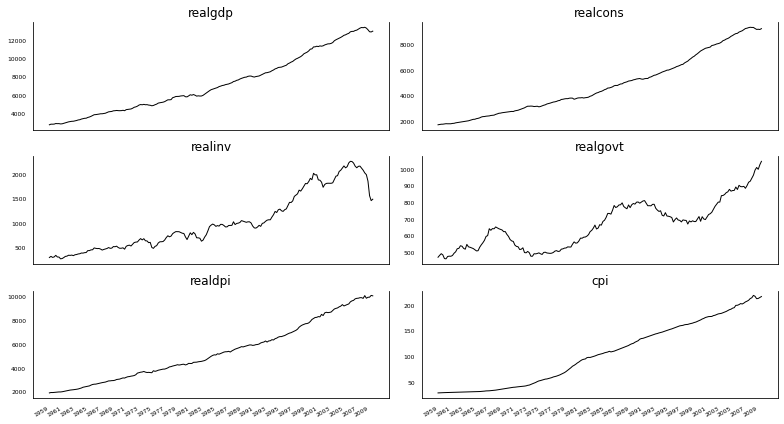

In [33]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(11,6))
for i, ax in enumerate(axes.flatten()[:6]):
    data = df_s[df_s.columns[i+2]]
    
    ax.plot(data, color='black', linewidth=1)
    ax.set_title(df_s.columns[i+2])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.setp(axes, xticks=np.arange(0, 208, 8), xticklabels=np.arange(1959, 2010, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Todo parece moverse de forma que una explica la otra

Veamos si nuestro target es estacionario o no...

In [34]:
y = df_s['realgdp']
ad_fuller_result = adfuller(y)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 1.7504627967647166
p-value: 0.9982455372335032


Claramente no lo es, veamos si lo diferenciamos.

In [35]:
ad_fuller_result = adfuller(y.diff().dropna())
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -6.305695561658106
p-value: 3.327882187668224e-08


Ahora si, es una serie estacionaria, con esto ya se que mi valor d=1. Veamos distintos valores y establezcamos el mejor resultado según criterio AIC, dejemos que la busqueda exhaustiva determine si hay alguna estacionalidad no visible.

In [36]:
p = range(0, 4, 1)
d = 1
q = range(0, 4, 1)
P = range(0, 4, 1)
D = 0
Q = range(0, 4, 1)
s = 4 #porque los datos son tomados trimestralmente
parameters = product(p, q, P, Q)
parameters_list = list(parameters)

target = df_s[[ 'realgdp' ]]
exog = df_s[['realcons', 'realinv', 'realgovt', 'realdpi', "cpi"]]

target_train = target.loc[ :200 ]
exo_train = exog.loc[ :200 ]

In [37]:
if os.path.exists("SARIMAX_AIC_results.csv"):
    result_df = pd.read_csv("SARIMAX_AIC_results.csv")
else:
    results = []
    for order in parameters_list:
        try: 
            model = SARIMAX(
                target_train,
                exo_train,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    result_df.to_csv("SARIMAX_AIC_results.csv", index=False)

In [38]:
result_df.sort_values(by='AIC', ascending=True).head(10)

,"(p,q,P,Q)",AIC
0,"(2, 3, 0, 0)",1755.785970
1,"(3, 3, 0, 0)",1757.055051
2,"(2, 3, 1, 0)",1759.087323
3,"(3, 3, 0, 1)",1759.132833
4,"(3, 3, 1, 0)",1759.179217
5,"(2, 3, 0, 1)",1759.614767
6,"(3, 3, 2, 2)",1760.216112
7,"(3, 2, 0, 0)",1760.248998
8,"(3, 3, 2, 0)",1760.532316
9,"(3, 3, 0, 2)",1760.544489


In [39]:
best_model = SARIMAX(target_train, exo_train, order=(2,1,3), seasonal_order=(0,0,0,s), simple_differencing=False)
best_model_fit = best_model.fit(disp=False)
print(best_model_fit.summary())  

                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  201
Model:               SARIMAX(2, 1, 3)   Log Likelihood                -866.893
Date:                Tue, 03 Mar 2026   AIC                           1755.786
Time:                        18:23:59   BIC                           1792.067
Sample:                             0   HQIC                          1770.469
                                - 201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9861      0.045     22.012      0.000       0.898       1.074
realinv        0.9707      0.025     38.483      0.000       0.921       1.020
realgovt       0.6957      0.124      5.631      0.0

c:\Users\pabli\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


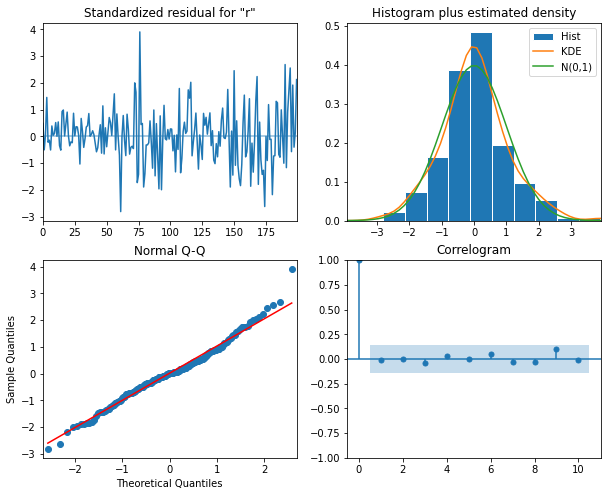

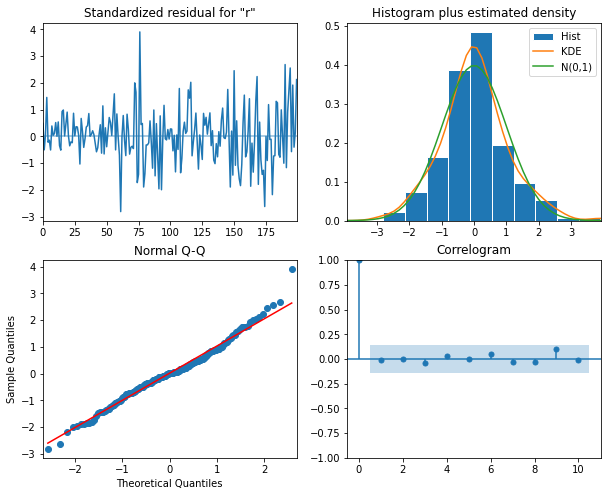

In [40]:
best_model_fit.plot_diagnostics(figsize=(10,8))

p-valor mayor que 0.05, no rechazamos la hipótesis nula y concluimos que los residuos son independientes y no correlacionados.

In [41]:
residuals = best_model_fit.resid
acorr_ljungbox(residuals, np.arange(1, 11, 1)).iloc[0:1, 1]


1    0.856394
Name: lb_pvalue, dtype: float64

In [42]:
def SARIMAX_rolling_forecast(endog, exog, train_len, horizon, window, method, order=(1, 0, 0), seasonal_order=(0, 0, 0, 0)):
    
    total_len = train_len + horizon

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = endog[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'SARIMAX':
        pred_SARIMAX = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog[:i], order=order, seasonal_order=seasonal_order, simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(exog=exog)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMAX.extend(oos_pred)
            
        return pred_SARIMAX
    else:
        raise Exception("Not implemented yet")

In [43]:
target_train = target[:196]     
target_test = target[196:]
TRAIN_LEN = len(target_train)
HORIZON = len(target_test)
WINDOW = 1 

In [44]:
target_test["realgdp"]

196    13366.865
197    13415.266
198    13324.600
199    13141.920
200    12925.410
201    12901.504
202    12990.341
Name: realgdp, dtype: float64

In [45]:
pred_df = pd.DataFrame({'actual': target_test["realgdp"]})

,realgdp
0,2710.349
1,2778.801
2,2775.488
3,2785.204
4,2847.699
...,...
198,13324.600
199,13141.920
200,12925.410
201,12901.504


In [51]:
pred_last_value = SARIMAX_rolling_forecast(target["realgdp"], exog, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_SARIMAX = SARIMAX_rolling_forecast(target["realgdp"], exog, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX')

pred_df['pred_last_value'] = pred_last_value
pred_df['pred_SARIMAX'] = pred_SARIMAX

c:\Users\pabli\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\pabli\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\pabli\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\pabli\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

In [52]:
pred_df

,actual,pred_last_value,pred_SARIMAX
196,13366.865,13391.249,13331.013343
197,13415.266,13366.865,13362.686532
198,13324.600,13415.266,13363.562468
199,13141.920,13324.600,13314.957141
200,12925.410,13141.920,13112.651185
201,12901.504,12925.410,12883.901974
202,12990.341,12901.504,12859.898281


0.736849498653785 0.6940650666404634


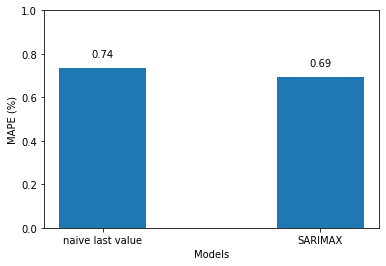

In [54]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_last = mape(pred_df.actual, pred_df.pred_last_value)
mape_SARIMAX = mape(pred_df.actual, pred_df.pred_SARIMAX)

print(mape_last, mape_SARIMAX)
fig, ax = plt.subplots()

x = ['naive last value', 'SARIMAX']
y = [mape_last, mape_SARIMAX]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 1)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 0.05, s=str(round(value,2)), ha='center')

plt.show()

Gana sarimax, aunque probablemente por menos de lo que pensabas!